# **EfficientNetB7 w/o XAI**

In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4090


2025-07-20 17:43:42.823410: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-20 17:43:43.946128: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753011824.243090     692 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753011824.312684     692 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753011825.049886     692 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Found 1614 images belonging to 5 classes.
Found 230 images belonging to 5 classes.
Found 466 images belonging to 5 classes.


I0000 00:00:1753011851.020201     692 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21458 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 380, 380,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 380, 380,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 380, 380,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 380, 380,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 381, 381,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 190, 190,  │      1,296 │ stem_conv_pad[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 190, 190,  │        192 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 190, 190,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 190, 190,  │        432 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 190, 190,  │        192 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 190, 190,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 48)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 48)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 12)  │        588 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 48)  │        624 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 190, 190,  │          0 │ block1a_activati… │
│ (Multiply)          │ 48)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 190, 190,  │      1,152 │ block1a_se_excit

...

37/51 ━━━━━━━━━━━━━━━━━━━━ 9s 677ms/step - accuracy: 0.1869 - loss: 1.6883 

2025-07-20 17:45:18.479039: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-07-20 17:45:18.609933: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-07-20 17:45:18.723593: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-07-20 17:45:19.067063: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-07-20 17:45:19.160467: E external/local_xla/xla/stream_

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 948ms/step - accuracy: 0.1893 - loss: 1.6795

2025-07-20 17:45:41.630045: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3998', 76 bytes spill stores, 76 bytes spill loads

2025-07-20 17:45:41.650810: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3998', 212 bytes spill stores, 212 bytes spill loads

2025-07-20 17:45:41.928685: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3998', 1604 bytes spill stores, 1604 bytes spill loads

2025-07-20 17:45:42.042120: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3998', 6096 bytes spill stores, 6052 bytes spill loads

2025-07-20 17:45:46.348529: I 

51/51 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.1895 - loss: 1.6789 - val_accuracy: 0.2739 - val_loss: 1.5565
Epoch 2/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 23s 450ms/step - accuracy: 0.2897 - loss: 1.5739 - val_accuracy: 0.3174 - val_loss: 1.4968
Epoch 3/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 23s 457ms/step - accuracy: 0.3136 - loss: 1.5358 - val_accuracy: 0.3522 - val_loss: 1.4544
Epoch 4/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 23s 447ms/step - accuracy: 0.3504 - loss: 1.4948 - val_accuracy: 0.4217 - val_loss: 1.4140
Epoch 5/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 23s 445ms/step - accuracy: 0.3917 - loss: 1.4500 - val_accuracy: 0.4478 - val_loss: 1.3828
Epoch 6/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 23s 443ms/step - accuracy: 0.4064 - loss: 1.4304 - val_accuracy: 0.4565 - val_loss: 1.3568
Epoch 7/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 23s 451ms/step - accuracy: 0.4205 - loss: 1.3852 - val_accuracy: 0.4652 - val_loss: 1.3345
Epoch 8/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 23s 452ms/step - accuracy: 0.4172 - loss: 1.3727 - val_accuracy: 0

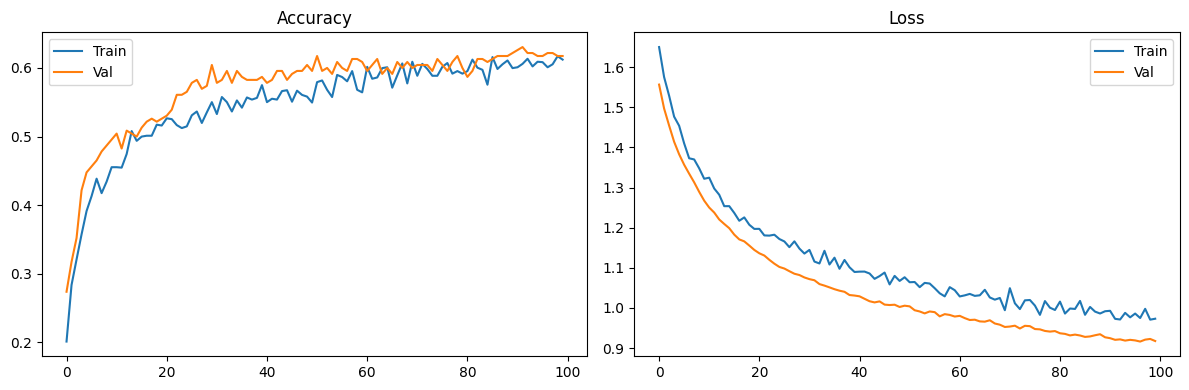

14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.7020 - loss: 0.7971

2025-07-20 18:24:08.188296: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3998', 132 bytes spill stores, 132 bytes spill loads

2025-07-20 18:24:08.199681: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3998', 224 bytes spill stores, 224 bytes spill loads

2025-07-20 18:24:08.360796: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3998', 4848 bytes spill stores, 4984 bytes spill loads

2025-07-20 18:24:08.441949: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3998', 5248 bytes spill stores, 5380 bytes spill loads

2025-07-20 18:24:09.060061: 

15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.6950 - loss: 0.8139 

Test Accuracy : 0.6459
Test Loss     : 0.9310
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 399ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.83      0.68       101
           1       0.62      0.59      0.60        99
           2       0.57      0.43      0.49        94
           3       0.82      0.67      0.74        89
           4       0.71      0.71      0.71        83

    accuracy                           0.65       466
   macro avg       0.66      0.65      0.64       466
weighted avg       0.65      0.65      0.64       466

Precision (weighted): 0.6546
Recall    (weighted): 0.6459
F1 score  (weighted): 0.6416


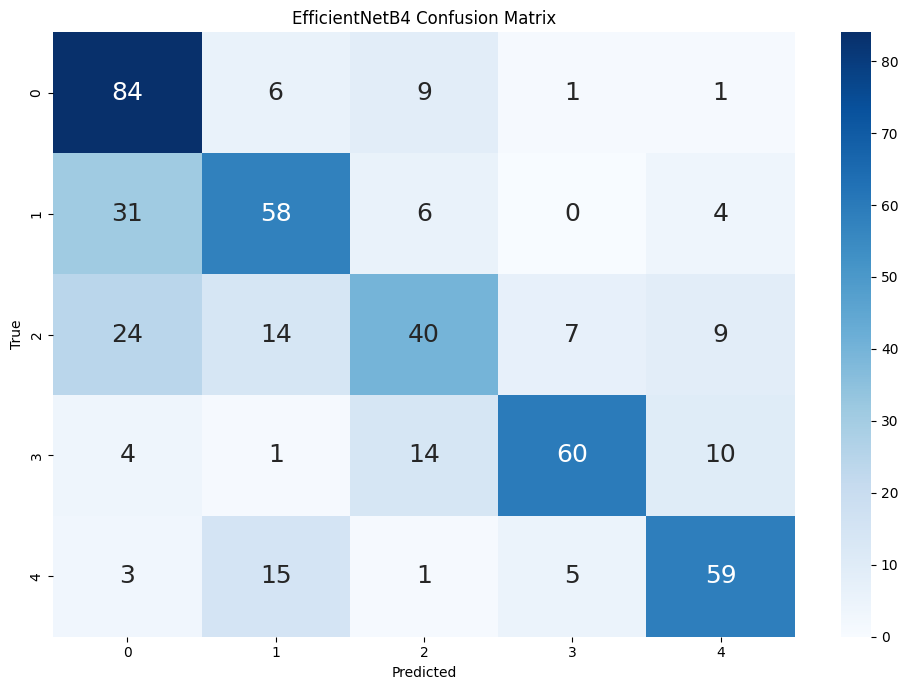

In [ ]:
"""
Baseline EfficientNetB4 (minimal edits) for 5-class knee-X-ray classification.

Directory layout expected:
E:/FA011/MSC/SplittedDataset/{train|val|test}/<class_name>/*.png|*.jpg
"""

# ─────────────────────────── 1. IMPORTS ────────────────────────────────────
import os, cv2, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.efficientnet import preprocess_input

from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score)

# ──────────────────────── 2. DATA & PARAMETERS ────────────────────────────
TRAIN_DIR = '/mnt/d/FA019/new/SplittedDataset/train'
VAL_DIR   ='/mnt/d/FA019/new/SplittedDataset/val'
TEST_DIR  = '/mnt/d/FA019/new/SplittedDataset/test'

IMG_SIZE   = (380, 380)          # native EfficientNetB4 resolution
BATCH_SIZE = 32
NUM_CLASSES = len(os.listdir(TRAIN_DIR))

# ─────────────────────────── 3. BPHE FUNCTION ─────────────────────────────
def bphe_rgb(img):
    """
    Brightness Preserving Histogram Equalization on Y channel,
    then EfficientNet's preprocess_input.
    """
    if img.max() <= 1.0:
        img = (img * 255).astype(np.uint8)
    else:
        img = img.astype(np.uint8)

    ycrcb = cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb)
    y, cr, cb = cv2.split(ycrcb)
    y_eq = cv2.equalizeHist(y)
    img_eq = cv2.cvtColor(cv2.merge((y_eq, cr, cb)), cv2.COLOR_YCrCb2RGB)
    return preprocess_input(img_eq.astype(np.float32))

# ───────────────────── 4. IMAGE GENERATORS ────────────────────────────────
train_gen = ImageDataGenerator(
    preprocessing_function=bphe_rgb,
    rotation_range=30, width_shift_range=0.2, height_shift_range=0.2,
    shear_range=0.2, zoom_range=0.2, horizontal_flip=True,
    brightness_range=[0.8, 1.2], fill_mode='nearest'
).flow_from_directory(TRAIN_DIR, target_size=IMG_SIZE,
                      batch_size=BATCH_SIZE, class_mode='categorical')

val_gen = ImageDataGenerator(preprocessing_function=bphe_rgb
).flow_from_directory(VAL_DIR, target_size=IMG_SIZE,
                      batch_size=BATCH_SIZE, class_mode='categorical')

test_gen = ImageDataGenerator(preprocessing_function=bphe_rgb
).flow_from_directory(TEST_DIR, target_size=IMG_SIZE,
                      batch_size=BATCH_SIZE, class_mode='categorical',
                      shuffle=False)

# ─────────────────────── 5. BUILD MODEL ───────────────────────────────────
base = EfficientNetB4(weights='imagenet',
                      include_top=True,   # keep original top
                      input_shape=IMG_SIZE + (3,))

# Replace 1 000-class Dense with 5-class Dense
x = base.layers[-2].output          # penultimate layer (before 1000-way head)
pred = Dense(NUM_CLASSES, activation='softmax', name='pred')(x)
model = Model(inputs=base.input, outputs=pred)

# Freeze backbone (all layers except new Dense)
for layer in base.layers:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# ──────────────────────── 6. TRAIN BASELINE ───────────────────────────────
history = model.fit(
    train_gen,
    epochs=100,                       # short run; fine-tune later
    validation_data=val_gen
)

# ──────────────────────── 7. PLOTS ────────────────────────────────────────
plt.figure(figsize=(12,4))
plt.subplot(1,2,1); plt.plot(history.history['accuracy']); plt.plot(history.history['val_accuracy'])
plt.title('Accuracy'); plt.legend(['Train','Val'])
plt.subplot(1,2,2); plt.plot(history.history['loss']); plt.plot(history.history['val_loss'])
plt.title('Loss'); plt.legend(['Train','Val'])
plt.tight_layout(); plt.show()

# ─────────────────────── 8. EVALUATION ────────────────────────────────────
test_loss, test_acc = model.evaluate(test_gen)
print(f"\nTest Accuracy : {test_acc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

# Predictions
test_gen.reset()
prob = model.predict(test_gen)
y_pred = np.argmax(prob, axis=1)
y_true = test_gen.classes

# Metrics
conf_mat = confusion_matrix(y_true, y_pred)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=test_gen.class_indices))

print(f"Precision (weighted): {precision_score(y_true, y_pred, average='weighted'):.4f}")
print(f"Recall    (weighted): {recall_score(y_true, y_pred, average='weighted'):.4f}")
print(f"F1 score  (weighted): {f1_score(y_true, y_pred, average='weighted'):.4f}")

# Confusion-matrix heat-map
plt.figure(figsize=(10,7))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_gen.class_indices, yticklabels=test_gen.class_indices,
            annot_kws={'size':18})
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('EfficientNetB4 Confusion Matrix')
plt.tight_layout(); plt.show()


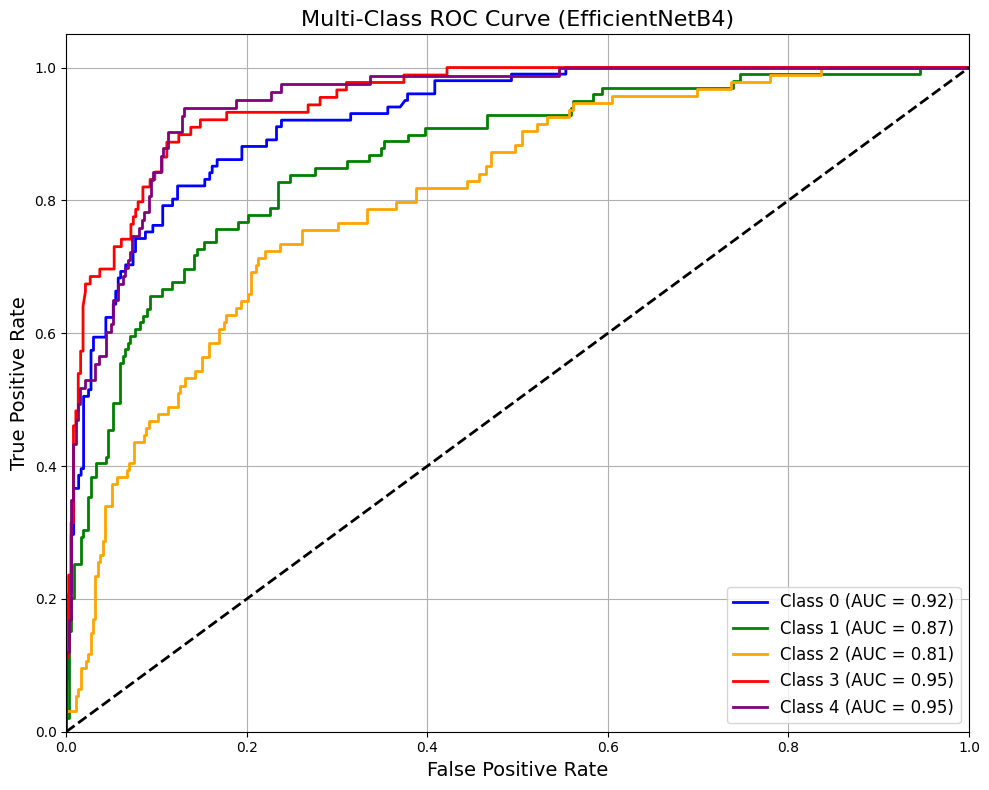

In [3]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize true labels for ROC computation
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

# Ensure we have prediction probabilities
y_score = prob  # already predicted via model.predict(test_gen)

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'orange', 'red', 'purple']
for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # diagonal
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Multi-Class ROC Curve (EfficientNetB4)', fontsize=16)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


In [4]:
#EfficientNetB5

Found 1614 images belonging to 5 classes.
Found 230 images belonging to 5 classes.
Found 466 images belonging to 5 classes.
123465288/123465288 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 456, 456,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 456, 456,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 456, 456,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 456, 456,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 457, 457,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 228, 228,  │      1,296 │ stem_conv_pad[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 228, 228,  │        192 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 228, 228,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 228, 228,  │        432 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 228, 228,  │        192 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 228, 228,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 48)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 48)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 12)  │        588 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 48)  │        624 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 228, 228,  │          0 │ block1a_activati… │
│ (Multiply)          │ 48)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 228, 228,  │      1,152 │ block1a_se_excit

 Total params: 28,523,772 (108.81 MB)

 Trainable params: 10,245 (40.02 KB)

...

42/51 ━━━━━━━━━━━━━━━━━━━━ 5s 577ms/step - accuracy: 0.1837 - loss: 1.6844

2025-07-20 18:25:47.016355: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-07-20 18:25:47.144555: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-07-20 18:25:47.454962: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-07-20 18:25:47.557480: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-07-20 18:25:48.317958: E external/local_xla/xla/stream_

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1868 - loss: 1.6796

2025-07-20 18:26:13.899086: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4824', 76 bytes spill stores, 76 bytes spill loads

2025-07-20 18:26:13.955741: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4824', 212 bytes spill stores, 212 bytes spill loads

2025-07-20 18:26:14.044972: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4824', 3816 bytes spill stores, 3796 bytes spill loads

2025-07-20 18:26:14.173083: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4824', 4168 bytes spill stores, 4152 bytes spill loads

2025-07-20 18:26:18.374332: I 

51/51 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.1871 - loss: 1.6791 - val_accuracy: 0.2913 - val_loss: 1.5573
Epoch 2/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 31s 598ms/step - accuracy: 0.2711 - loss: 1.5750 - val_accuracy: 0.3217 - val_loss: 1.5067
Epoch 3/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 31s 603ms/step - accuracy: 0.2985 - loss: 1.5293 - val_accuracy: 0.3565 - val_loss: 1.4622
Epoch 4/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 31s 603ms/step - accuracy: 0.3427 - loss: 1.4877 - val_accuracy: 0.3913 - val_loss: 1.4263
Epoch 5/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 31s 610ms/step - accuracy: 0.3653 - loss: 1.4589 - val_accuracy: 0.4348 - val_loss: 1.3982
Epoch 6/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 31s 606ms/step - accuracy: 0.3740 - loss: 1.4366 - val_accuracy: 0.4565 - val_loss: 1.3695
Epoch 7/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 31s 604ms/step - accuracy: 0.4137 - loss: 1.3910 - val_accuracy: 0.4609 - val_loss: 1.3503
Epoch 8/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 31s 603ms/step - accuracy: 0.4207 - loss: 1.3812 - val_accuracy: 

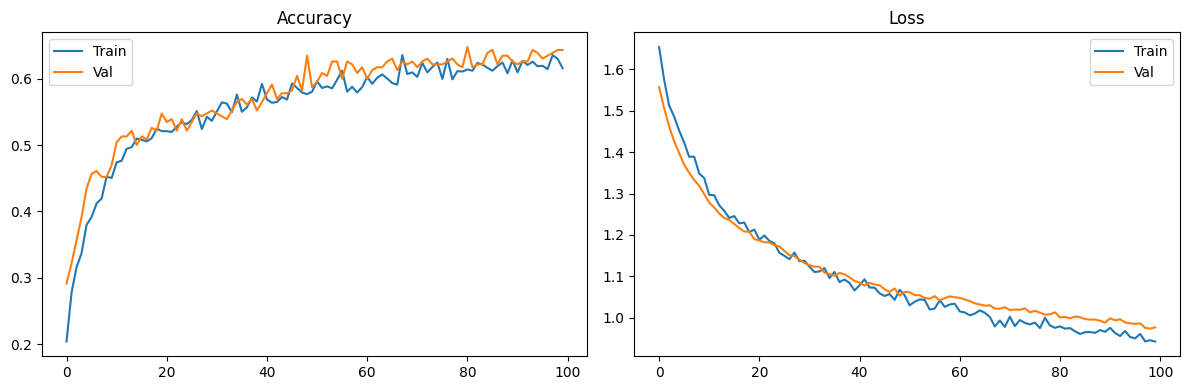

14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.7187 - loss: 0.8076

2025-07-20 19:17:36.847913: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4824', 4444 bytes spill stores, 4156 bytes spill loads

2025-07-20 19:17:36.847950: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4824', 132 bytes spill stores, 132 bytes spill loads

2025-07-20 19:17:36.848006: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4824', 4 bytes spill stores, 4 bytes spill loads

2025-07-20 19:17:36.848409: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4824', 224 bytes spill stores, 224 bytes spill loads

2025-07-20 19:17:36.849393: I exte

15/15 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.7066 - loss: 0.8303 

Test Accuracy : 0.6223
Test Loss     : 0.9890
15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 479ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.88      0.71       101
           1       0.49      0.57      0.52        99
           2       0.57      0.40      0.47        94
           3       0.82      0.55      0.66        89
           4       0.79      0.70      0.74        83

    accuracy                           0.62       466
   macro avg       0.65      0.62      0.62       466
weighted avg       0.64      0.62      0.62       466

Precision (weighted): 0.6431
Recall    (weighted): 0.6223
F1 score  (weighted): 0.6176


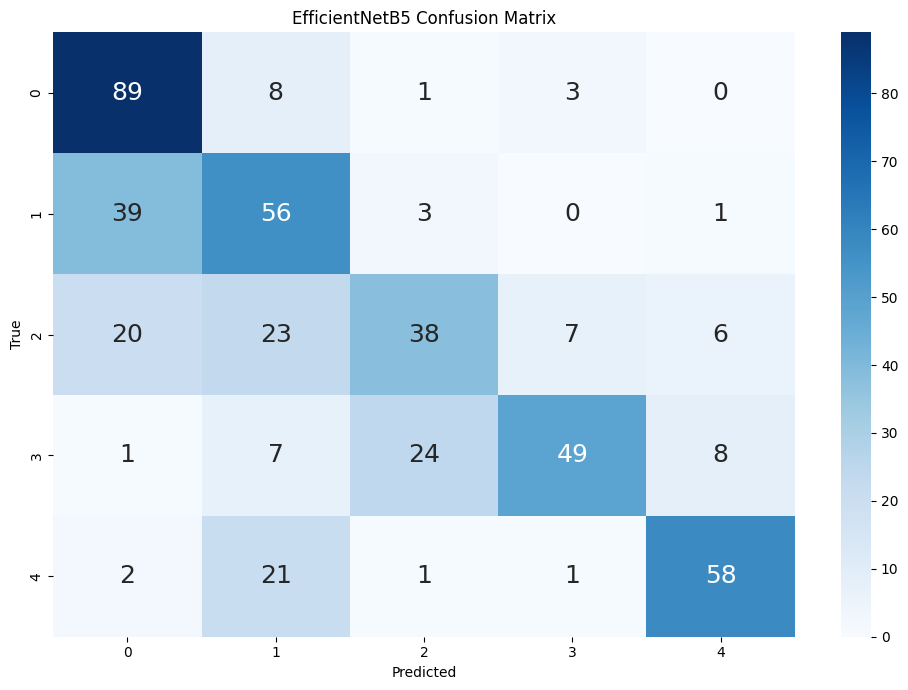

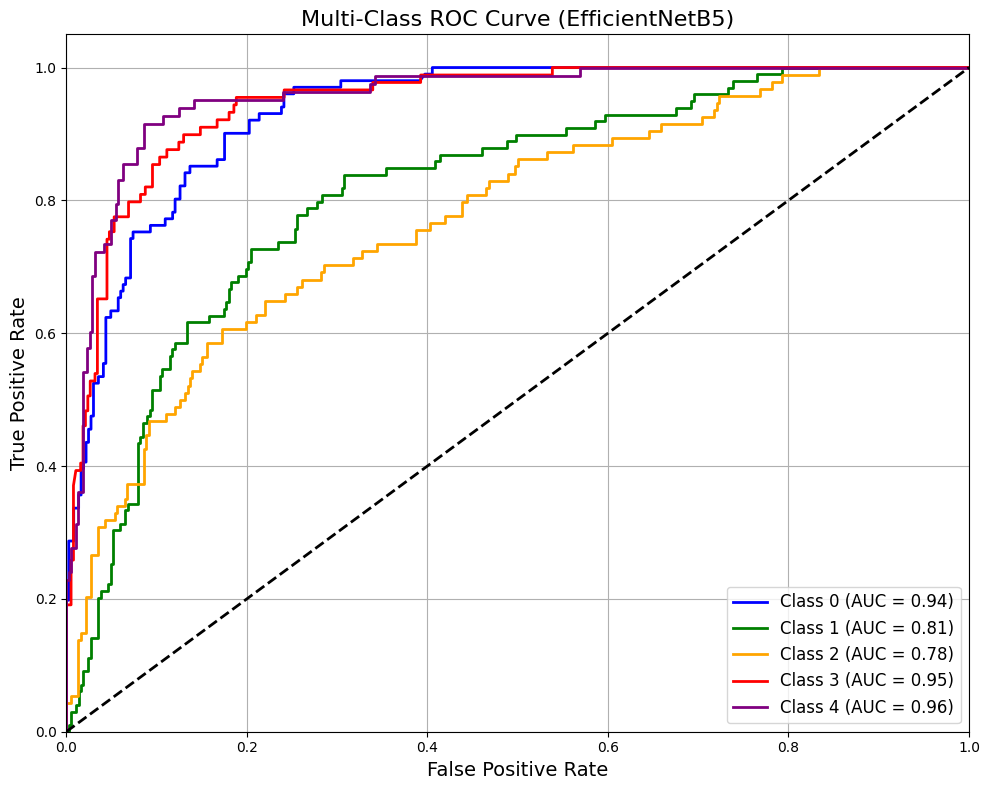

In [5]:
"""
Baseline EfficientNetB5 (minimal edits) for 5-class knee-X-ray classification.

Directory layout expected:
E:/FA011/MSC/SplittedDataset/{train|val|test}/<class_name>/*.png|*.jpg
"""

# ─────────────────────────── 1. IMPORTS ────────────────────────────────────
import os, cv2, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB5
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.efficientnet import preprocess_input

from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score)

# ──────────────────────── 2. DATA & PARAMETERS ────────────────────────────
TRAIN_DIR = '/mnt/d/FA019/SplitDataset/train'
VAL_DIR   = '/mnt/d/FA019/SplitDataset/val'
TEST_DIR  = '/mnt/d/FA019/SplitDataset/test'

IMG_SIZE   = (456, 456)          # native EfficientNetB5 resolution
BATCH_SIZE = 32
NUM_CLASSES = len(os.listdir(TRAIN_DIR))

# ─────────────────────────── 3. BPHE FUNCTION ─────────────────────────────
def bphe_rgb(img):
    """
    Brightness Preserving Histogram Equalization on Y channel,
    then EfficientNet's preprocess_input.
    """
    if img.max() <= 1.0:
        img = (img * 255).astype(np.uint8)
    else:
        img = img.astype(np.uint8)

    ycrcb = cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb)
    y, cr, cb = cv2.split(ycrcb)
    y_eq = cv2.equalizeHist(y)
    img_eq = cv2.cvtColor(cv2.merge((y_eq, cr, cb)), cv2.COLOR_YCrCb2RGB)
    return preprocess_input(img_eq.astype(np.float32))

# ───────────────────── 4. IMAGE GENERATORS ────────────────────────────────
train_gen = ImageDataGenerator(
    preprocessing_function=bphe_rgb,
    rotation_range=30, width_shift_range=0.2, height_shift_range=0.2,
    shear_range=0.2, zoom_range=0.2, horizontal_flip=True,
    brightness_range=[0.8, 1.2], fill_mode='nearest'
).flow_from_directory(TRAIN_DIR, target_size=IMG_SIZE,
                      batch_size=BATCH_SIZE, class_mode='categorical')

val_gen = ImageDataGenerator(preprocessing_function=bphe_rgb
).flow_from_directory(VAL_DIR, target_size=IMG_SIZE,
                      batch_size=BATCH_SIZE, class_mode='categorical')

test_gen = ImageDataGenerator(preprocessing_function=bphe_rgb
).flow_from_directory(TEST_DIR, target_size=IMG_SIZE,
                      batch_size=BATCH_SIZE, class_mode='categorical',
                      shuffle=False)

# ─────────────────────── 5. BUILD MODEL ───────────────────────────────────
base = EfficientNetB5(weights='imagenet',
                      include_top=True,   # keep original top
                      input_shape=IMG_SIZE + (3,))

# Replace 1 000-class Dense with 5-class Dense
x = base.layers[-2].output          # penultimate layer (before 1000-way head)
pred = Dense(NUM_CLASSES, activation='softmax', name='pred')(x)
model = Model(inputs=base.input, outputs=pred)

# Freeze backbone (all layers except new Dense)
for layer in base.layers:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# ──────────────────────── 6. TRAIN BASELINE ───────────────────────────────
history = model.fit(
    train_gen,
    epochs=100,                       # short run; fine-tune later
    validation_data=val_gen
)

# ──────────────────────── 7. PLOTS ────────────────────────────────────────
plt.figure(figsize=(12,4))
plt.subplot(1,2,1); plt.plot(history.history['accuracy']); plt.plot(history.history['val_accuracy'])
plt.title('Accuracy'); plt.legend(['Train','Val'])
plt.subplot(1,2,2); plt.plot(history.history['loss']); plt.plot(history.history['val_loss'])
plt.title('Loss'); plt.legend(['Train','Val'])
plt.tight_layout(); plt.show()

# ─────────────────────── 8. EVALUATION ────────────────────────────────────
test_loss, test_acc = model.evaluate(test_gen)
print(f"\nTest Accuracy : {test_acc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

# Predictions
test_gen.reset()
prob = model.predict(test_gen)
y_pred = np.argmax(prob, axis=1)
y_true = test_gen.classes

# Metrics
conf_mat = confusion_matrix(y_true, y_pred)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=test_gen.class_indices))

print(f"Precision (weighted): {precision_score(y_true, y_pred, average='weighted'):.4f}")
print(f"Recall    (weighted): {recall_score(y_true, y_pred, average='weighted'):.4f}")
print(f"F1 score  (weighted): {f1_score(y_true, y_pred, average='weighted'):.4f}")

# Confusion-matrix heat-map
plt.figure(figsize=(10,7))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_gen.class_indices, yticklabels=test_gen.class_indices,
            annot_kws={'size':18})
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('EfficientNetB5 Confusion Matrix')
plt.tight_layout(); plt.show()

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize true labels for ROC computation
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

# Ensure we have prediction probabilities
y_score = prob  # already predicted via model.predict(test_gen)

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'orange', 'red', 'purple']
for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # diagonal
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Multi-Class ROC Curve (EfficientNetB5)', fontsize=16)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()



Found 1614 images belonging to 5 classes.
Found 230 images belonging to 5 classes.
Found 466 images belonging to 5 classes.
21834768/21834768 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_4         │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_2     │ (None, 224, 224,  │          7 │ rescaling_4[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_5         │ (None, 224, 224,  │          0 │ normalization_2[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_5[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 6,405 (25.02 KB)

...

23/51 ━━━━━━━━━━━━━━━━━━━━ 5s 198ms/step - accuracy: 0.1933 - loss: 1.7473

2025-07-20 19:18:30.095519: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-07-20 19:18:30.230516: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-07-20 19:18:30.371208: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-07-20 19:18:30.516311: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-07-20 19:18:30.661537: E external/local_xla/xla/stream_

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.1998 - loss: 1.7279

2025-07-20 19:18:42.047271: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2074', 212 bytes spill stores, 212 bytes spill loads

2025-07-20 19:18:42.061261: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2074', 84 bytes spill stores, 84 bytes spill loads

2025-07-20 19:18:42.296156: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2074', 1604 bytes spill stores, 1604 bytes spill loads

2025-07-20 19:18:42.364347: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2074', 6096 bytes spill stores, 6052 bytes spill loads

2025-07-20 19:18:44.893834: I 

51/51 ━━━━━━━━━━━━━━━━━━━━ 41s 521ms/step - accuracy: 0.2000 - loss: 1.7273 - val_accuracy: 0.2609 - val_loss: 1.6160
Epoch 2/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 213ms/step - accuracy: 0.2305 - loss: 1.6254 - val_accuracy: 0.2783 - val_loss: 1.5487
Epoch 3/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 213ms/step - accuracy: 0.2723 - loss: 1.5868 - val_accuracy: 0.3435 - val_loss: 1.5013
Epoch 4/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 216ms/step - accuracy: 0.3309 - loss: 1.5215 - val_accuracy: 0.3696 - val_loss: 1.4637
Epoch 5/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 209ms/step - accuracy: 0.3692 - loss: 1.4726 - val_accuracy: 0.3739 - val_loss: 1.4357
Epoch 6/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 209ms/step - accuracy: 0.3448 - loss: 1.4661 - val_accuracy: 0.3957 - val_loss: 1.4082
Epoch 7/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 213ms/step - accuracy: 0.3803 - loss: 1.4310 - val_accuracy: 0.4261 - val_loss: 1.3832
Epoch 8/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 214ms/step - accuracy: 0.4275 - loss: 1.4009 - val_accuracy

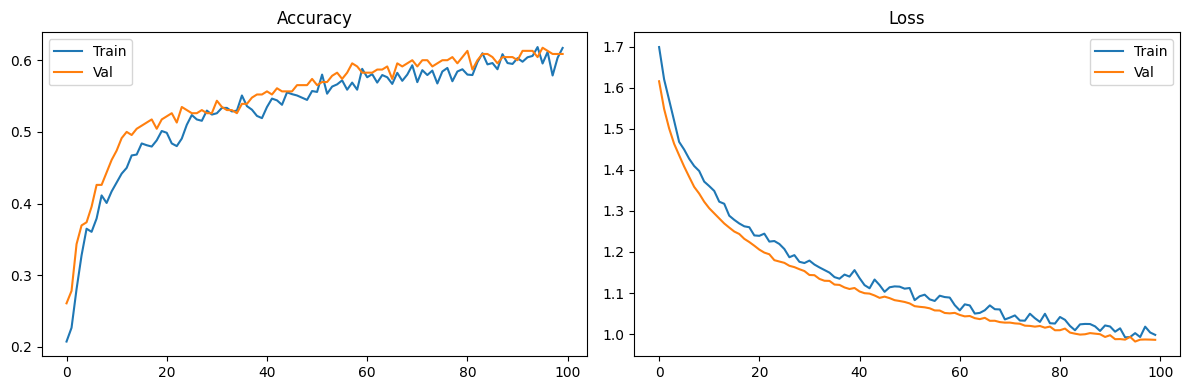

13/15 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.6467 - loss: 0.8769

2025-07-20 19:36:54.246653: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2074', 120 bytes spill stores, 120 bytes spill loads

2025-07-20 19:36:54.292860: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2074', 224 bytes spill stores, 224 bytes spill loads

2025-07-20 19:36:54.490002: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2074', 4848 bytes spill stores, 4984 bytes spill loads

2025-07-20 19:36:54.569945: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2074', 5248 bytes spill stores, 5380 bytes spill loads

2025-07-20 19:36:56.468122: 

15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 601ms/step - accuracy: 0.6373 - loss: 0.9039

Test Accuracy : 0.5987
Test Loss     : 1.0186
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 252ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.82      0.61       101
           1       0.54      0.40      0.46        99
           2       0.54      0.32      0.40        94
           3       0.78      0.69      0.73        89
           4       0.75      0.78      0.76        83

    accuracy                           0.60       466
   macro avg       0.62      0.60      0.59       466
weighted avg       0.61      0.60      0.59       466

Precision (weighted): 0.6105
Recall    (weighted): 0.5987
F1 score  (weighted): 0.5869


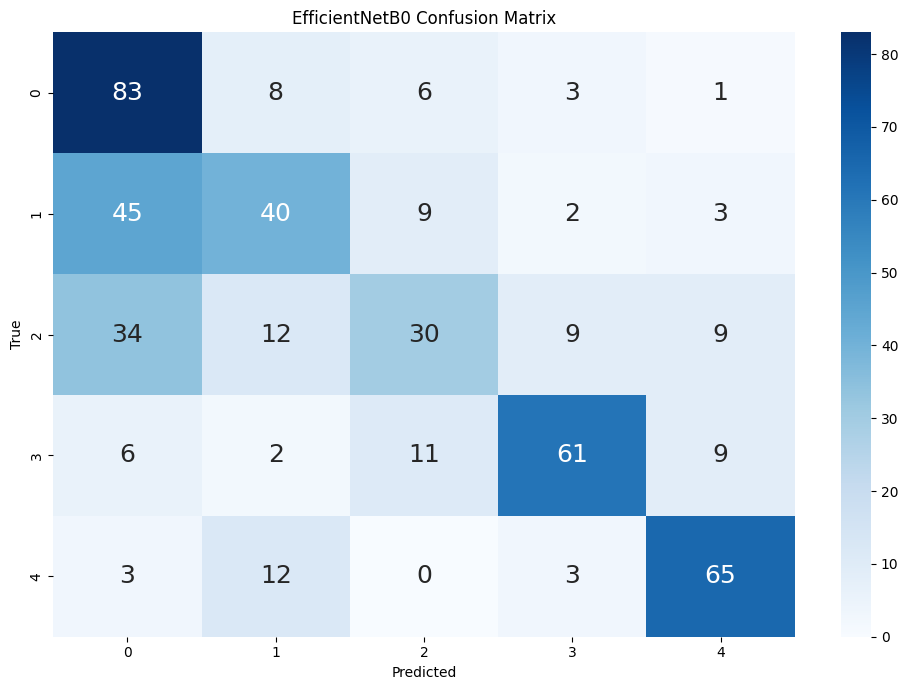

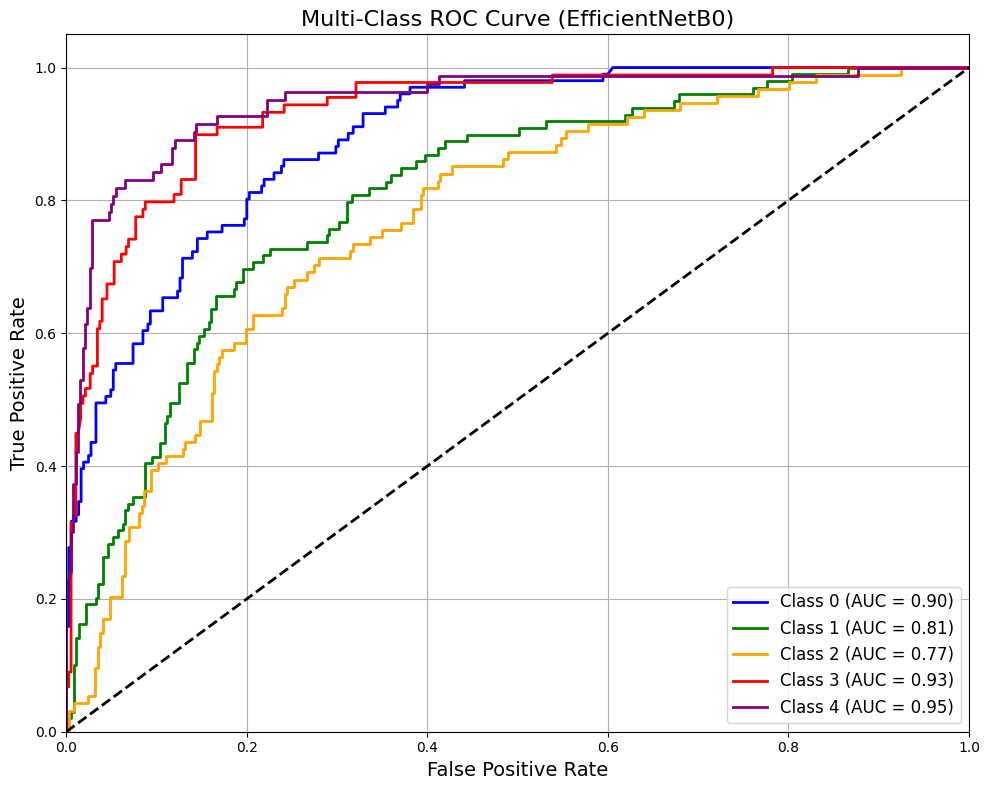

In [6]:
"""
Baseline EfficientNetB0 (minimal edits) for 5-class knee-X-ray classification.

Directory layout expected:
E:/FA011/MSC/SplittedDataset/{train|val|test}/<class_name>/*.png|*.jpg
"""

# ─────────────────────────── 1. IMPORTS ────────────────────────────────────
import os, cv2, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.efficientnet import preprocess_input

from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score)

# ──────────────────────── 2. DATA & PARAMETERS ────────────────────────────
TRAIN_DIR = '/mnt/d/FA019/SplitDataset/train'
VAL_DIR   = '/mnt/d/FA019/SplitDataset/val'
TEST_DIR  = '/mnt/d/FA019/SplitDataset/test'

IMG_SIZE   = (224, 224)          # native EfficientNetB7 resolution
BATCH_SIZE = 32
NUM_CLASSES = len(os.listdir(TRAIN_DIR))

# ─────────────────────────── 3. BPHE FUNCTION ─────────────────────────────
def bphe_rgb(img):
    """
    Brightness Preserving Histogram Equalization on Y channel,
    then EfficientNet's preprocess_input.
    """
    if img.max() <= 1.0:
        img = (img * 255).astype(np.uint8)
    else:
        img = img.astype(np.uint8)

    ycrcb = cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb)
    y, cr, cb = cv2.split(ycrcb)
    y_eq = cv2.equalizeHist(y)
    img_eq = cv2.cvtColor(cv2.merge((y_eq, cr, cb)), cv2.COLOR_YCrCb2RGB)
    return preprocess_input(img_eq.astype(np.float32))

# ───────────────────── 4. IMAGE GENERATORS ────────────────────────────────
train_gen = ImageDataGenerator(
    preprocessing_function=bphe_rgb,
    rotation_range=30, width_shift_range=0.2, height_shift_range=0.2,
    shear_range=0.2, zoom_range=0.2, horizontal_flip=True,
    brightness_range=[0.8, 1.2], fill_mode='nearest'
).flow_from_directory(TRAIN_DIR, target_size=IMG_SIZE,
                      batch_size=BATCH_SIZE, class_mode='categorical')

val_gen = ImageDataGenerator(preprocessing_function=bphe_rgb
).flow_from_directory(VAL_DIR, target_size=IMG_SIZE,
                      batch_size=BATCH_SIZE, class_mode='categorical')

test_gen = ImageDataGenerator(preprocessing_function=bphe_rgb
).flow_from_directory(TEST_DIR, target_size=IMG_SIZE,
                      batch_size=BATCH_SIZE, class_mode='categorical',
                      shuffle=False)

# ─────────────────────── 5. BUILD MODEL ───────────────────────────────────
base = EfficientNetB0(weights='imagenet',
                      include_top=True,   # keep original top
                      input_shape=IMG_SIZE + (3,))

# Replace 1 000-class Dense with 5-class Dense
x = base.layers[-2].output          # penultimate layer (before 1000-way head)
pred = Dense(NUM_CLASSES, activation='softmax', name='pred')(x)
model = Model(inputs=base.input, outputs=pred)

# Freeze backbone (all layers except new Dense)
for layer in base.layers:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# ──────────────────────── 6. TRAIN BASELINE ───────────────────────────────
history = model.fit(
    train_gen,
    epochs=100,                       # short run; fine-tune later
    validation_data=val_gen
)

# ──────────────────────── 7. PLOTS ────────────────────────────────────────
plt.figure(figsize=(12,4))
plt.subplot(1,2,1); plt.plot(history.history['accuracy']); plt.plot(history.history['val_accuracy'])
plt.title('Accuracy'); plt.legend(['Train','Val'])
plt.subplot(1,2,2); plt.plot(history.history['loss']); plt.plot(history.history['val_loss'])
plt.title('Loss'); plt.legend(['Train','Val'])
plt.tight_layout(); plt.show()

# ─────────────────────── 8. EVALUATION ────────────────────────────────────
test_loss, test_acc = model.evaluate(test_gen)
print(f"\nTest Accuracy : {test_acc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

# Predictions
test_gen.reset()
prob = model.predict(test_gen)
y_pred = np.argmax(prob, axis=1)
y_true = test_gen.classes

# Metrics
conf_mat = confusion_matrix(y_true, y_pred)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=test_gen.class_indices))

print(f"Precision (weighted): {precision_score(y_true, y_pred, average='weighted'):.4f}")
print(f"Recall    (weighted): {recall_score(y_true, y_pred, average='weighted'):.4f}")
print(f"F1 score  (weighted): {f1_score(y_true, y_pred, average='weighted'):.4f}")

# Confusion-matrix heat-map
plt.figure(figsize=(10,7))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_gen.class_indices, yticklabels=test_gen.class_indices,
            annot_kws={'size':18})
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('EfficientNetB0 Confusion Matrix')
plt.tight_layout(); plt.show()

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize true labels for ROC computation
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

# Ensure we have prediction probabilities
y_score = prob  # already predicted via model.predict(test_gen)

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'orange', 'red', 'purple']
for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # diagonal
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Multi-Class ROC Curve (EfficientNetB0)', fontsize=16)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

